# Исследование данных

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime
import json
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

In [46]:
%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

In [47]:
PROJECT_ROOT = Path.cwd()  
DATA_DIR = PROJECT_ROOT / "data" / "raw"

Загрузка данных

In [48]:
print("Загрузка events.csv...")
events_df = pd.read_csv(DATA_DIR / "events.csv")
print(f"Размер: {events_df.shape}")
print(f"Память: {events_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
events_df.head()

Загрузка events.csv...
Размер: (2756101, 5)
Память: 223.90 MB


,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN
3,1433221955914,483717,view,253185,NaN
4,1433221337106,951259,view,367447,NaN


In [49]:
print("\nЗагрузка item_properties.csv...")
try:
    item_props_df = pd.read_csv(DATA_DIR / "item_properties.csv")
    print(f"Размер: {item_props_df.shape}")
    print(f"Память: {item_props_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    item_props_df.head()
except FileNotFoundError:
    print("Файл item_properties.csv не найден")
    item_props_df = None



Загрузка item_properties.csv...
Файл item_properties.csv не найден


In [50]:
print("\nЗагрузка category_tree.csv...")
try:
    category_df = pd.read_csv(DATA_DIR / "category_tree.csv")
    print(f"Размер: {category_df.shape}")
    category_df.head()
except FileNotFoundError:
    print("Файл category_tree.csv не найден")
    category_df = None



Загрузка category_tree.csv...
Размер: (1669, 2)


In [51]:
print("=== БАЗОВАЯ ИНФОРМАЦИЯ О СОБЫТИЯХ ===")
print(f"Всего событий: {len(events_df):,}")
print(f"Период данных: {pd.to_datetime(events_df['timestamp'], unit='ms').min()} - {pd.to_datetime(events_df['timestamp'], unit='ms').max()}")
print(f"Уникальных пользователей: {events_df['visitorid'].nunique():,}")
print(f"Уникальных товаров: {events_df['itemid'].nunique():,}")

=== БАЗОВАЯ ИНФОРМАЦИЯ О СОБЫТИЯХ ===
Всего событий: 2,756,101
Период данных: 2015-05-03 03:00:04.384000 - 2015-09-18 02:59:47.788000
Уникальных пользователей: 1,407,580
Уникальных товаров: 235,061


## Исследование событий (events.csv)

Преобразуем timestamp

In [52]:
events_df['datetime'] = pd.to_datetime(events_df['timestamp'], unit='ms')
events_df['date'] = events_df['datetime'].dt.date
events_df['day_of_week'] = events_df['datetime'].dt.day_name()
events_df['hour'] = events_df['datetime'].dt.hour
events_df['month'] = events_df['datetime'].dt.to_period('M')

In [53]:
print("\n=== РАСПРЕДЕЛЕНИЕ СОБЫТИЙ ===")
event_counts = events_df['event'].value_counts()
event_percentages = events_df['event'].value_counts(normalize=True) * 100

event_stats = pd.DataFrame({
    'Количество': event_counts,
    'Процент': event_percentages.round(2)
})
print(event_stats)


=== РАСПРЕДЕЛЕНИЕ СОБЫТИЙ ===
             Количество  Процент
event                           
view            2664312    96.67
addtocart         69332     2.52
transaction       22457     0.81


In [54]:
print("КОНВЕРСИОННАЯ ВОРОНКА")
view_sessions = events_df[events_df['event'] == 'view']['visitorid'].nunique()
addtocart_sessions = events_df[events_df['event'] == 'addtocart']['visitorid'].nunique()
transaction_sessions = events_df[events_df['event'] == 'transaction']['visitorid'].nunique()

funnel_data = pd.DataFrame({
    'Этап': ['Просмотр', 'Добавление в корзину', 'Покупка'],
    'Уникальные пользователи': [view_sessions, addtocart_sessions, transaction_sessions],
    'Конверсия от предыдущего': ['-', 
                                f"{(addtocart_sessions/view_sessions*100):.2f}%",
                                f"{(transaction_sessions/addtocart_sessions*100):.2f}%"],
    'Общая конверсия': [f"{(view_sessions/view_sessions*100):.2f}%",
                       f"{(addtocart_sessions/view_sessions*100):.2f}%",
                       f"{(transaction_sessions/view_sessions*100):.2f}%"]
})
print(funnel_data)

КОНВЕРСИОННАЯ ВОРОНКА
                   Этап  Уникальные пользователи Конверсия от предыдущего  \
0              Просмотр                  1404179                        -   
1  Добавление в корзину                    37722                    2.69%   
2               Покупка                    11719                   31.07%   

  Общая конверсия  
0         100.00%  
1           2.69%  
2           0.83%  


## Временной анализ

ВРЕМЕННОЙ АНАЛИЗ


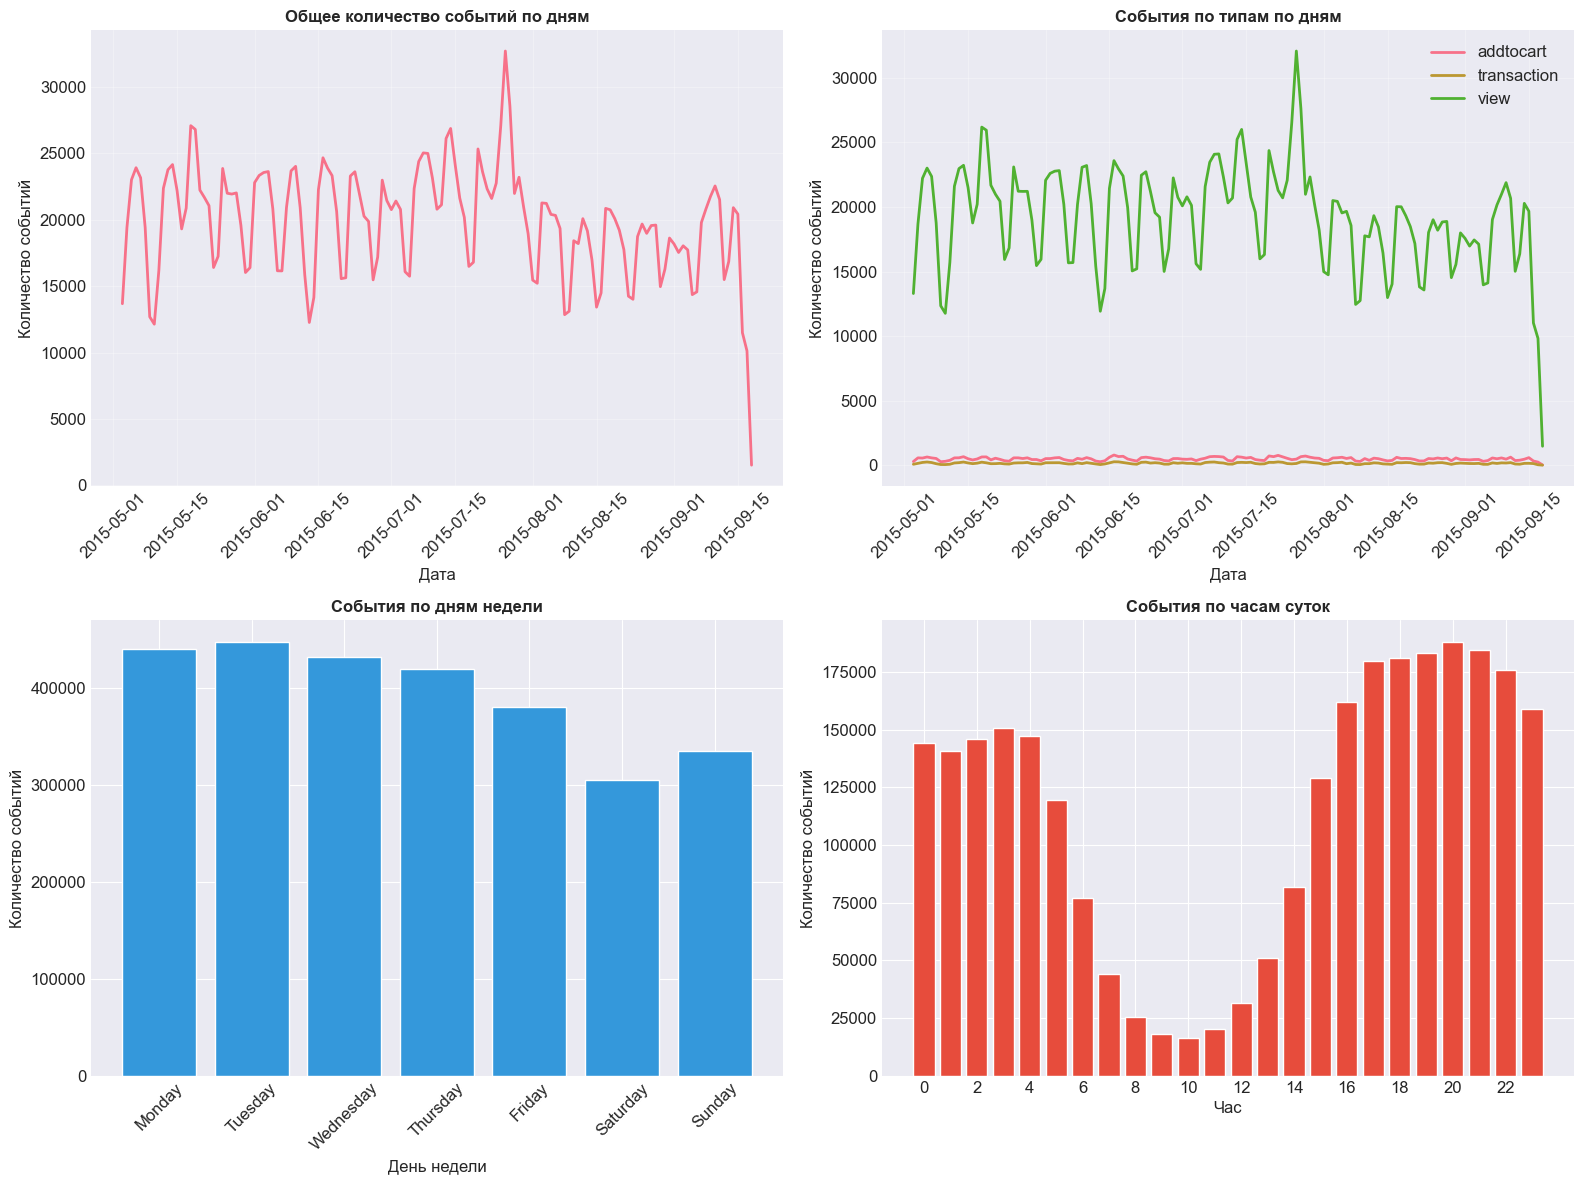

In [55]:
print("ВРЕМЕННОЙ АНАЛИЗ")

daily_events = events_df.groupby('date').size()
daily_events_by_type = events_df.groupby(['date', 'event']).size().unstack(fill_value=0)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].plot(daily_events.index, daily_events.values, linewidth=2)
axes[0, 0].set_title('Общее количество событий по дням', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Дата')
axes[0, 0].set_ylabel('Количество событий')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].tick_params(axis='x', rotation=45)

for event_type in daily_events_by_type.columns:
    axes[0, 1].plot(daily_events_by_type.index, daily_events_by_type[event_type], 
                    label=event_type, linewidth=2)
axes[0, 1].set_title('События по типам по дням', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Дата')
axes[0, 1].set_ylabel('Количество событий')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].tick_params(axis='x', rotation=45)

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_events = events_df['day_of_week'].value_counts().reindex(day_order)
axes[1, 0].bar(day_order, day_events.values, color='#3498db')
axes[1, 0].set_title('События по дням недели', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('День недели')
axes[1, 0].set_ylabel('Количество событий')
axes[1, 0].tick_params(axis='x', rotation=45)

hourly_events = events_df['hour'].value_counts().sort_index()
axes[1, 1].bar(hourly_events.index, hourly_events.values, color='#e74c3c')
axes[1, 1].set_title('События по часам суток', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Час')
axes[1, 1].set_ylabel('Количество событий')
axes[1, 1].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.show()

In [56]:
# Месячный тренд
monthly_stats = events_df.groupby('month').agg({
    'visitorid': 'nunique',
    'itemid': 'nunique',
    'event': 'count'
}).rename(columns={
    'visitorid': 'Уникальные пользователи',
    'itemid': 'Уникальные товары',
    'event': 'Всего событий'
})

print("\nСтатистика по месяцам:")
print(monthly_stats)



Статистика по месяцам:
         Уникальные пользователи  Уникальные товары  Всего событий
month                                                             
2015-05                   307574             114802         590652
2015-06                   313832             117317         610393
2015-07                   377199             126671         697984
2015-08                   311128             114050         553362
2015-09                   173728              82220         303710


## Анализ пользователей

In [57]:
print("АНАЛИЗ ПОЛЬЗОВАТЕЛЕЙ")

# Статистика по пользователям
user_stats = events_df.groupby('visitorid').agg({
    'itemid': ['nunique', 'count'],
    'event': lambda x: (x == 'transaction').sum(),
    'datetime': ['min', 'max']
}).round(2)

user_stats.columns = ['Уникальных_товаров', 'Всего_событий', 'Покупок', 'Первое_событие', 'Последнее_событие']
user_stats['Дней_активности'] = (user_stats['Последнее_событие'] - user_stats['Первое_событие']).dt.days + 1
user_stats['Событий_в_день'] = user_stats['Всего_событий'] / user_stats['Дней_активности']

print("\nСтатистика по пользователям:")
print(user_stats.describe())


АНАЛИЗ ПОЛЬЗОВАТЕЛЕЙ

Статистика по пользователям:
       Уникальных_товаров  Всего_событий       Покупок  \
count        1.407580e+06   1.407580e+06  1.407580e+06   
mean         1.524019e+00   1.958042e+00  1.595433e-02   
min          1.000000e+00   1.000000e+00  0.000000e+00   
25%          1.000000e+00   1.000000e+00  0.000000e+00   
50%          1.000000e+00   1.000000e+00  0.000000e+00   
75%          1.000000e+00   2.000000e+00  0.000000e+00   
max          3.814000e+03   7.757000e+03  5.590000e+02   
std          7.143724e+00   1.258049e+01  8.260909e-01   

                   Первое_событие           Последнее_событие  \
count                     1407580                     1407580   
mean   2015-07-09 10:16:42.513000  2015-07-11 19:17:24.858000   
min    2015-05-03 03:00:04.384000  2015-05-03 03:00:11.289000   
25%    2015-06-04 21:48:25.778000  2015-06-08 00:56:58.077000   
50%    2015-07-10 10:54:21.271000  2015-07-13 01:08:21.987000   
75%    2015-08-11 00:00:35.832000  2

Распределение активности пользователей

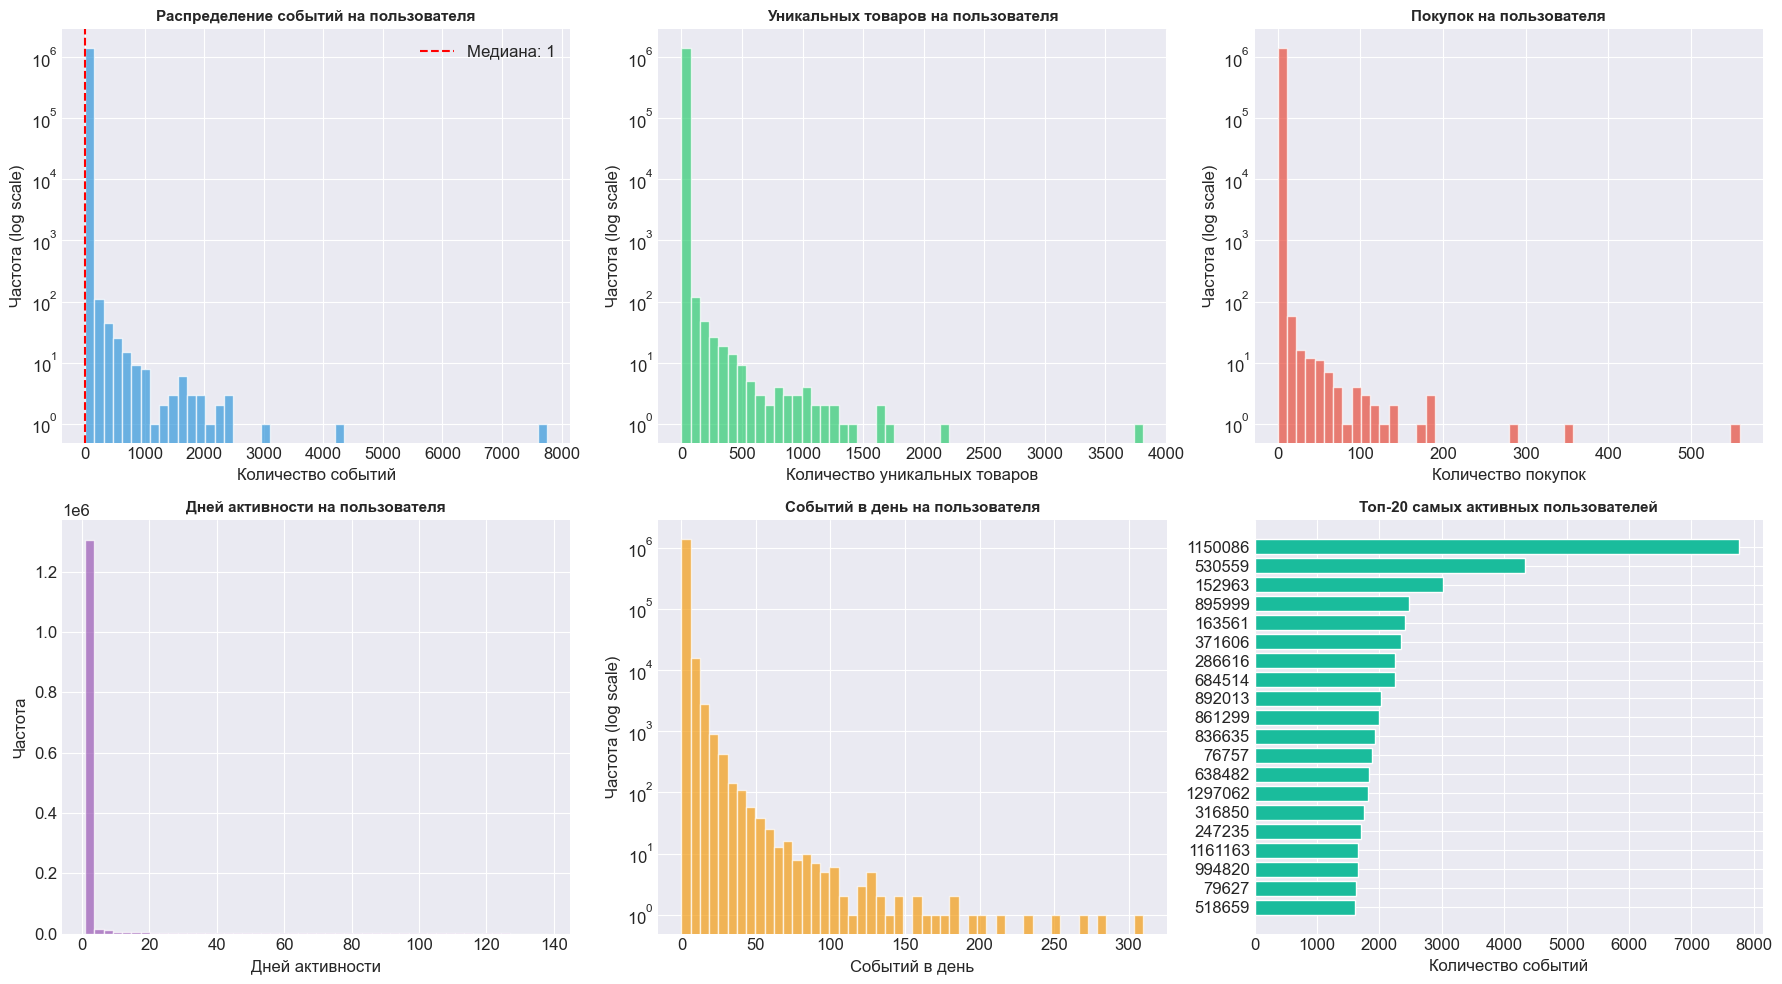

In [58]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0, 0].hist(user_stats['Всего_событий'], bins=50, log=True, color='#3498db', alpha=0.7)
axes[0, 0].set_title('Распределение событий на пользователя', fontsize=11, fontweight='bold')
axes[0, 0].set_xlabel('Количество событий')
axes[0, 0].set_ylabel('Частота (log scale)')
axes[0, 0].axvline(user_stats['Всего_событий'].median(), color='red', linestyle='--', label=f'Медиана: {user_stats["Всего_событий"].median():.0f}')
axes[0, 0].legend()

axes[0, 1].hist(user_stats['Уникальных_товаров'], bins=50, log=True, color='#2ecc71', alpha=0.7)
axes[0, 1].set_title('Уникальных товаров на пользователя', fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel('Количество уникальных товаров')
axes[0, 1].set_ylabel('Частота (log scale)')

axes[0, 2].hist(user_stats['Покупок'], bins=50, log=True, color='#e74c3c', alpha=0.7)
axes[0, 2].set_title('Покупок на пользователя', fontsize=11, fontweight='bold')
axes[0, 2].set_xlabel('Количество покупок')
axes[0, 2].set_ylabel('Частота (log scale)')

axes[1, 0].hist(user_stats['Дней_активности'], bins=50, color='#9b59b6', alpha=0.7)
axes[1, 0].set_title('Дней активности на пользователя', fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel('Дней активности')
axes[1, 0].set_ylabel('Частота')

axes[1, 1].hist(user_stats['Событий_в_день'], bins=50, log=True, color='#f39c12', alpha=0.7)
axes[1, 1].set_title('Событий в день на пользователя', fontsize=11, fontweight='bold')
axes[1, 1].set_xlabel('Событий в день')
axes[1, 1].set_ylabel('Частота (log scale)')

top_users = user_stats.nlargest(20, 'Всего_событий')['Всего_событий']
axes[1, 2].barh(range(len(top_users)), top_users.values, color='#1abc9c')
axes[1, 2].set_yticks(range(len(top_users)))
axes[1, 2].set_yticklabels(top_users.index)
axes[1, 2].set_title('Топ-20 самых активных пользователей', fontsize=11, fontweight='bold')
axes[1, 2].set_xlabel('Количество событий')
axes[1, 2].invert_yaxis()

plt.tight_layout()
plt.show()

In [59]:
# Сегментация пользователей по активности
print("СЕГМЕНТАЦИЯ ПОЛЬЗОВАТЕЛЕЙ")

def segment_users(row):
    if row['Всего_событий'] >= 100:
        return 'Высокая активность'
    elif row['Всего_событий'] >= 10:
        return 'Средняя активность'
    else:
        return 'Низкая активность'

user_stats['Сегмент'] = user_stats.apply(segment_users, axis=1)
segment_counts = user_stats['Сегмент'].value_counts()

print("Распределение по сегментам активности:")
for segment, count in segment_counts.items():
    percentage = count / len(user_stats) * 100
    print(f"{segment}: {count:,} пользователей ({percentage:.1f}%)")

СЕГМЕНТАЦИЯ ПОЛЬЗОВАТЕЛЕЙ
Распределение по сегментам активности:
Низкая активность: 1,384,339 пользователей (98.3%)
Средняя активность: 22,824 пользователей (1.6%)
Высокая активность: 417 пользователей (0.0%)


## Анализ товаров

In [60]:
print("АНАЛИЗ ТОВАРОВ")
item_stats = events_df.groupby('itemid').agg({
    'visitorid': ['nunique', 'count'],
    'event': lambda x: (x == 'transaction').sum()
}).round(2)

item_stats.columns = ['Уникальных_пользователей', 'Всего_просмотров', 'Покупок']
item_stats['Конверсия'] = (item_stats['Покупок'] / item_stats['Всего_просмотров'] * 100).round(2)

print("\nСтатистика по товарам:")
print(item_stats.describe())

АНАЛИЗ ТОВАРОВ

Статистика по товарам:
       Уникальных_пользователей  Всего_просмотров        Покупок  \
count             235061.000000     235061.000000  235061.000000   
mean                   9.126052         11.725046       0.095537   
std                   27.102543         37.032101       0.738321   
min                    1.000000          1.000000       0.000000   
25%                    1.000000          1.000000       0.000000   
50%                    2.000000          3.000000       0.000000   
75%                    7.000000          9.000000       0.000000   
max                 2912.000000       3412.000000     133.000000   

           Конверсия  
count  235061.000000  
mean        0.251634  
std         1.559390  
min         0.000000  
25%         0.000000  
50%         0.000000  
75%         0.000000  
max       100.000000  


Популярость товаров

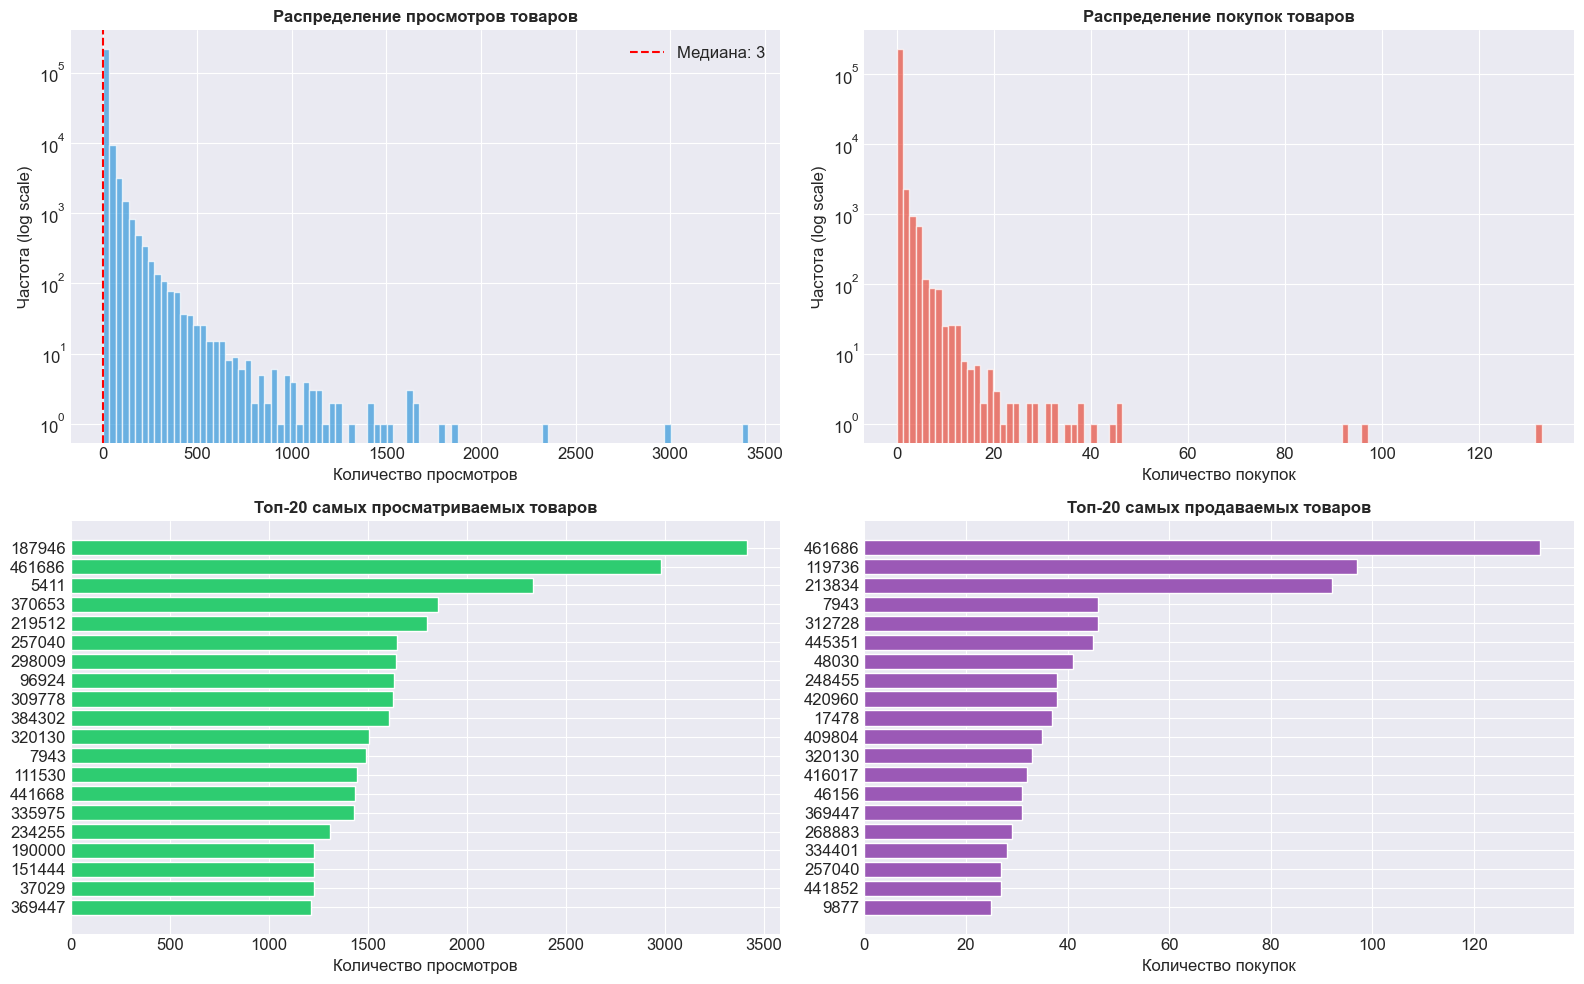

In [61]:

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].hist(item_stats['Всего_просмотров'], bins=100, log=True, color='#3498db', alpha=0.7)
axes[0, 0].set_title('Распределение просмотров товаров', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Количество просмотров')
axes[0, 0].set_ylabel('Частота (log scale)')
axes[0, 0].axvline(item_stats['Всего_просмотров'].median(), color='red', linestyle='--', 
                  label=f'Медиана: {item_stats["Всего_просмотров"].median():.0f}')
axes[0, 0].legend()

axes[0, 1].hist(item_stats['Покупок'], bins=100, log=True, color='#e74c3c', alpha=0.7)
axes[0, 1].set_title('Распределение покупок товаров', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Количество покупок')
axes[0, 1].set_ylabel('Частота (log scale)')

top_viewed = item_stats.nlargest(20, 'Всего_просмотров')['Всего_просмотров']
axes[1, 0].barh(range(len(top_viewed)), top_viewed.values, color='#2ecc71')
axes[1, 0].set_yticks(range(len(top_viewed)))
axes[1, 0].set_yticklabels(top_viewed.index)
axes[1, 0].set_title('Топ-20 самых просматриваемых товаров', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Количество просмотров')
axes[1, 0].invert_yaxis()

top_sold = item_stats[item_stats['Покупок'] > 0].nlargest(20, 'Покупок')['Покупок']
axes[1, 1].barh(range(len(top_sold)), top_sold.values, color='#9b59b6')
axes[1, 1].set_yticks(range(len(top_sold)))
axes[1, 1].set_yticklabels(top_sold.index)
axes[1, 1].set_title('Топ-20 самых продаваемых товаров', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Количество покупок')
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.show()


LONG-TAIL РАСПРЕДЕЛЕНИЕ
Топ-20% товаров генерируют 78.7% просмотров


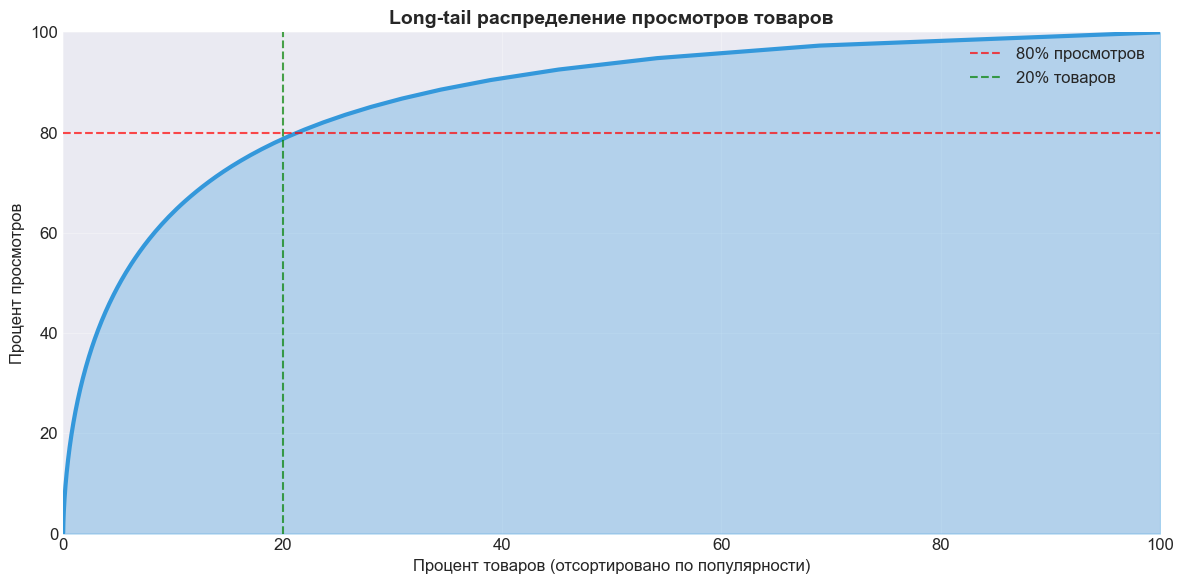

In [62]:
print("LONG-TAIL РАСПРЕДЕЛЕНИЕ")

# Сортировка товаров по популярности
sorted_items = item_stats.sort_values('Всего_просмотров', ascending=False)
sorted_items['cumulative_views'] = sorted_items['Всего_просмотров'].cumsum()
sorted_items['cumulative_percentage'] = sorted_items['cumulative_views'] / sorted_items['Всего_просмотров'].sum() * 100
sorted_items['item_rank'] = range(1, len(sorted_items) + 1)
sorted_items['rank_percentage'] = sorted_items['item_rank'] / len(sorted_items) * 100

# Нахождение точки 80/20
top_20_percent_items = sorted_items[sorted_items['rank_percentage'] <= 20]
top_20_views = top_20_percent_items['Всего_просмотров'].sum() / sorted_items['Всего_просмотров'].sum() * 100

print(f"Топ-20% товаров генерируют {top_20_views:.1f}% просмотров")

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(sorted_items['rank_percentage'], sorted_items['cumulative_percentage'], 
        linewidth=3, color='#3498db')
ax.fill_between(sorted_items['rank_percentage'], 0, sorted_items['cumulative_percentage'], 
                alpha=0.3, color='#3498db')
ax.axhline(y=80, color='red', linestyle='--', alpha=0.7, label='80% просмотров')
ax.axvline(x=20, color='green', linestyle='--', alpha=0.7, label='20% товаров')
ax.set_xlabel('Процент товаров (отсортировано по популярности)')
ax.set_ylabel('Процент просмотров')
ax.set_title('Long-tail распределение просмотров товаров', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

## Анализ сессий 

In [63]:
print("АНАЛИЗ СЕССИЙ ПОЛЬЗОВАТЕЛЕЙ")

# Группируем по пользователям и сортируем по времени и 
# вычисляем разницу во времени между последовательными событиями
events_df_sorted = events_df.sort_values(['visitorid', 'timestamp'])
events_df_sorted['time_diff'] = events_df_sorted.groupby('visitorid')['timestamp'].diff()

# Сессия заканчивается если разница > 30 минут
SESSION_GAP = 30 * 60 * 1000
events_df_sorted['new_session'] = (events_df_sorted['time_diff'].isna()) | (events_df_sorted['time_diff'] > SESSION_GAP)
events_df_sorted['session_id'] = events_df_sorted.groupby('visitorid')['new_session'].cumsum()

session_stats = events_df_sorted.groupby(['visitorid', 'session_id']).agg({
    'itemid': 'count',
    'datetime': ['min', 'max'],
    'event': lambda x: list(x)
}).round(2)

session_stats.columns = ['events_count', 'start_time', 'end_time', 'events_sequence']
session_stats['duration_minutes'] = (session_stats['end_time'] - session_stats['start_time']).dt.total_seconds() / 60

print(f"Всего сессий: {len(session_stats):,}")
print(f"Средняя длина сессии: {session_stats['events_count'].mean():.1f} событий")
print(f"Медианная длина сессии: {session_stats['events_count'].median():.1f} событий")
print(f"Средняя длительность сессии: {session_stats['duration_minutes'].mean():.1f} минут")

АНАЛИЗ СЕССИЙ ПОЛЬЗОВАТЕЛЕЙ
Всего сессий: 1,761,675
Средняя длина сессии: 1.6 событий
Медианная длина сессии: 1.0 событий
Средняя длительность сессии: 1.8 минут


Визуализация статистики сессий

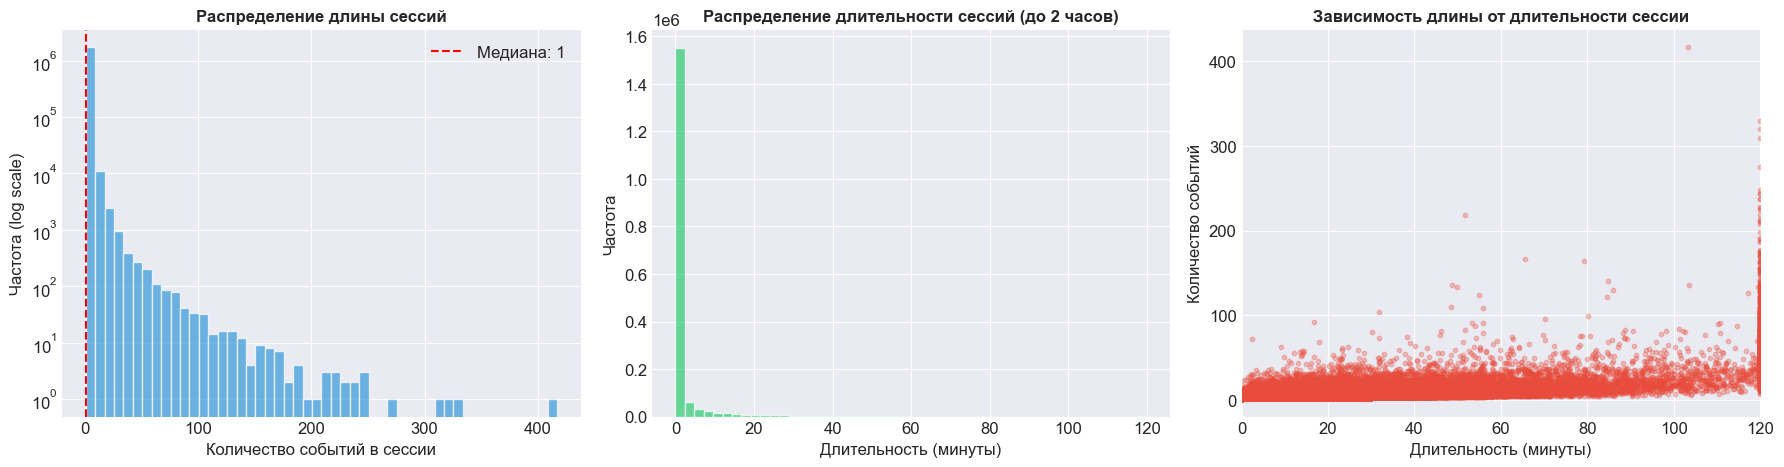

In [64]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(session_stats['events_count'], bins=50, log=True, color='#3498db', alpha=0.7)
axes[0].set_title('Распределение длины сессий', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Количество событий в сессии')
axes[0].set_ylabel('Частота (log scale)')
axes[0].axvline(session_stats['events_count'].median(), color='red', linestyle='--',
                label=f'Медиана: {session_stats["events_count"].median():.0f}')
axes[0].legend()

axes[1].hist(session_stats['duration_minutes'].clip(0, 120), bins=50, color='#2ecc71', alpha=0.7)
axes[1].set_title('Распределение длительности сессий (до 2 часов)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Длительность (минуты)')
axes[1].set_ylabel('Частота')

scatter = axes[2].scatter(session_stats['duration_minutes'].clip(0, 120), 
                         session_stats['events_count'], 
                         alpha=0.3, s=10, color='#e74c3c')
axes[2].set_title('Зависимость длины от длительности сессии', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Длительность (минуты)')
axes[2].set_ylabel('Количество событий')
axes[2].set_xlim(0, 120)

plt.tight_layout()
plt.show()

## Сводка и выводы

In [66]:
print("ОБЩАЯ СВОДКА ПО ДАННЫМ \n")

summary = {
    "Общая статистика": [
        f"Всего событий: {len(events_df):,}",
        f"Уникальных пользователей: {events_df['visitorid'].nunique():,}",
        f"Уникальных товаров: {events_df['itemid'].nunique():,}",
        f"Период данных: {events_df['datetime'].min().date()} - {events_df['datetime'].max().date()}"
    ],
    
    "Распределение событий": [
        f"Просмотры (view): {event_counts.get('view', 0):,} ({event_percentages.get('view', 0):.1f}%)",
        f"Добавления в корзину (addtocart): {event_counts.get('addtocart', 0):,} ({event_percentages.get('addtocart', 0):.1f}%)",
        f"Покупки (transaction): {event_counts.get('transaction', 0):,} ({event_percentages.get('transaction', 0):.1f}%)"
    ],
    
    "Конверсии": [
        f"View → AddToCart: {(addtocart_sessions/view_sessions*100):.2f}%",
        f"AddToCart → Transaction: {(transaction_sessions/addtocart_sessions*100):.2f}%",
        f"Общая конверсия: {(transaction_sessions/view_sessions*100):.2f}%"
    ],
    
    "Пользователи": [
        f"Среднее событий на пользователя: {user_stats['Всего_событий'].mean():.1f}",
        f"Медиана событий на пользователя: {user_stats['Всего_событий'].median():.1f}",
        f"Среднее покупок на пользователя: {user_stats['Покупок'].mean():.1f}"
    ],
    
    "Товары": [
        f"Среднее просмотров на товар: {item_stats['Всего_просмотров'].mean():.1f}",
        f"Медиана просмотров на товар: {item_stats['Всего_просмотров'].median():.1f}",
        f"Товаров с покупками: {(item_stats['Покупок'] > 0).sum():,}",
        f"Топ-20% товаров генерируют: {top_20_views:.1f}% просмотров"
    ],
    
    "Сессии": [
        f"Всего сессий: {len(session_stats):,}",
        f"Средняя длина сессии: {session_stats['events_count'].mean():.1f} событий",
        f"Средняя длительность сессии: {session_stats['duration_minutes'].mean():.1f} минут"
    ]
}

for category, items in summary.items():
    print(f"{category}:")
    for item in items:
        print(f"    {item}")
    print()

ОБЩАЯ СВОДКА ПО ДАННЫМ 

Общая статистика:
    Всего событий: 2,756,101
    Уникальных пользователей: 1,407,580
    Уникальных товаров: 235,061
    Период данных: 2015-05-03 - 2015-09-18

Распределение событий:
    Просмотры (view): 2,664,312 (96.7%)
    Добавления в корзину (addtocart): 69,332 (2.5%)
    Покупки (transaction): 22,457 (0.8%)

Конверсии:
    View → AddToCart: 2.69%
    AddToCart → Transaction: 31.07%
    Общая конверсия: 0.83%

Пользователи:
    Среднее событий на пользователя: 2.0
    Медиана событий на пользователя: 1.0
    Среднее покупок на пользователя: 0.0

Товары:
    Среднее просмотров на товар: 11.7
    Медиана просмотров на товар: 3.0
    Товаров с покупками: 12,025
    Топ-20% товаров генерируют: 78.7% просмотров

Сессии:
    Всего сессий: 1,761,675
    Средняя длина сессии: 1.6 событий
    Средняя длительность сессии: 1.8 минут

